In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

In [ ]:
df = pd.read_csv("/content/titanic_data_updated.csv")
df.drop(['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch'], axis=1, inplace=True)
X = df.drop(["Survived"], axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
age_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
age_imputer.fit(X_train[["Age"]])
X_train['Age'] = age_imputer.transform(X_train[["Age"]]).ravel()
X_test['Age'] = age_imputer.transform(X_test[['Age']])
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
embarked_imputer.fit(X_train[['Embarked']])
X_train['Embarked'] = embarked_imputer.transform(X_train[['Embarked']]).ravel() # 2D ---> 1D
X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel() # 2D ---> 1D
cabin_imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)
cabin_imputer.fit(X_train[['Cabin']])
X_train[['Cabin', 'cabin_missing_indicator']] = cabin_imputer.transform(X_train[['Cabin']])
X_test[['Cabin', 'cabin_missing_indicator']] = cabin_imputer.transform(X_test[['Cabin']])

<Axes: xlabel='Age', ylabel='Density'>

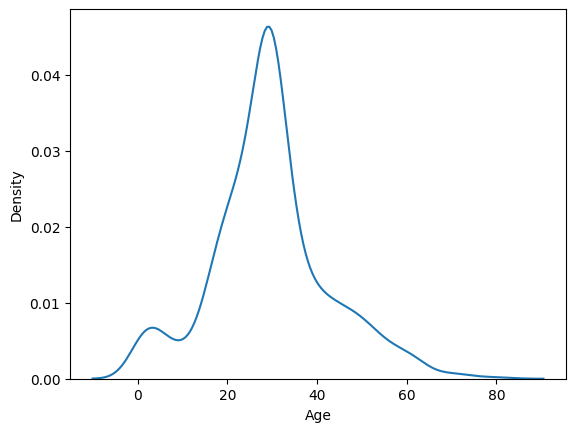

In [ ]:
sns.kdeplot(X_train, x='Age')

# Standard Scaling (Normal Distribution)

In [ ]:
ss = StandardScaler()

ss.fit(X_train[['Age']])

X_train['Age'] = ss.transform(X_train[['Age']]).ravel()
X_test['Age'] = ss.transform(X_test[['Age']]).ravel()

In [ ]:
X_train.sample(5)

,Pclass,Sex,Age,Fare,Cabin,Embarked,cabin_missing_indicator
723,second,male,1.578812e+00,13.0000,Missing,S,True
240,third,female,2.735977e-16,14.4542,Missing,C,True
525,third,male,8.472087e-01,7.7500,Missing,Q,True
505,first,male,-8.855364e-01,108.9000,C65,C,False
617,third,female,-2.694493e-01,16.1000,Missing,S,True


In [ ]:
round(X_train['Age'].mean(), 5)

np.float64(0.0)

In [ ]:
round(X_train['Age'].std(), 5)

1.0007

<Axes: xlabel='Age', ylabel='Density'>

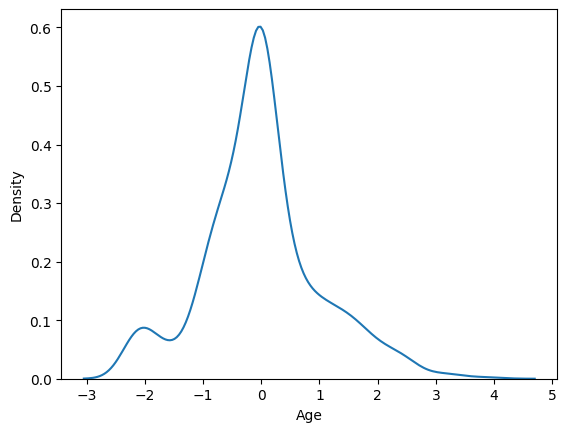

In [ ]:
sns.kdeplot(X_train, x='Age')

# Min-Max Scaling (NO Outliers)

*    (0 - 1)

<Axes: xlabel='Fare', ylabel='Density'>

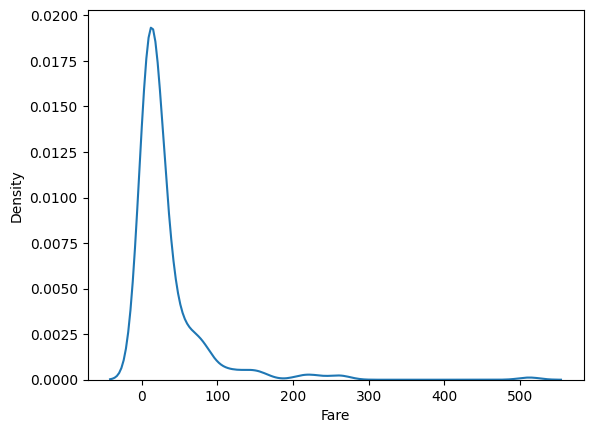

In [ ]:
sns.kdeplot(data=X_train, x='Fare')

In [ ]:
mms = MinMaxScaler()

mms.fit(X_train[['Fare']])
X_train['Fare'] = mms.transform(X_train[['Fare']]).ravel()
X_test['Fare'] = mms.transform(X_test[['Fare']]).ravel()

X_train['Fare'].describe()

,Fare
count,712.000000
mean,0.063604
std,0.101438
min,0.000000
25%,0.015469
50%,0.028213
75%,0.059532
max,1.000000


<Axes: xlabel='Fare', ylabel='Density'>

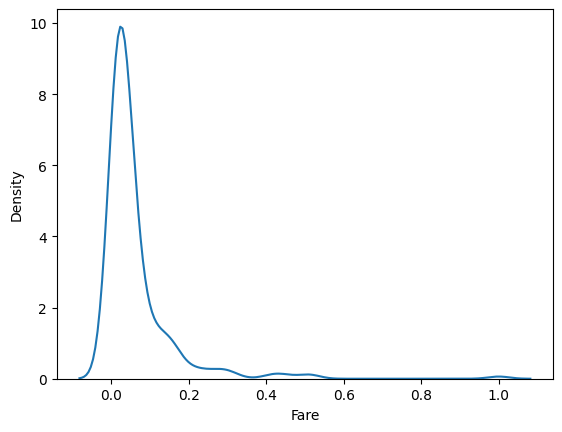

In [ ]:
sns.kdeplot(data=X_train, x='Fare')

# Robus Scaling (With Outliers)

*   Works on IQR

In [ ]:
df = pd.read_csv("/content/marks_dataset.csv")
df

,student_name,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
0,Mr. Gregory Homenick,69,24,52,4,83
1,Marlene Leffler IV,62,59,70,54,52
2,Josephine Ebert,29,76,13,8,19
3,Dr. Irene Green,44,66,14,2,14
4,Jake Huel,49,23,63,86,68
...,...,...,...,...,...,...
95,Renee Schinner,69,99,73,62,32
96,Marguerite Ebert,32,62,82,99,42
97,Jorge Bednar,77,56,46,79,25
98,Mrs. Roxanne Jacobi,54,66,70,49,20


<Axes: xlabel='maths_marks', ylabel='Density'>

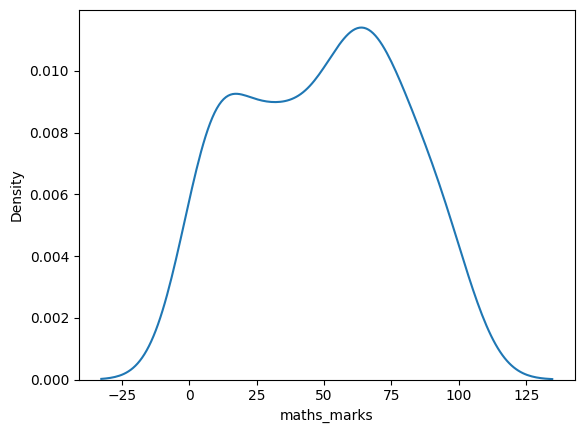

In [ ]:
sns.kdeplot(data=df, x="maths_marks")

In [ ]:
df['maths_marks'].describe()

,maths_marks
count,100.000000
mean,48.950000
std,28.999956
min,2.000000
25%,27.000000
50%,52.500000
75%,70.250000
max,100.000000


In [ ]:
rs = RobustScaler()

rs.fit(df[['maths_marks']])

df['maths_marks'] = rs.transform(df[['maths_marks']]).ravel()

<Axes: xlabel='maths_marks', ylabel='Density'>

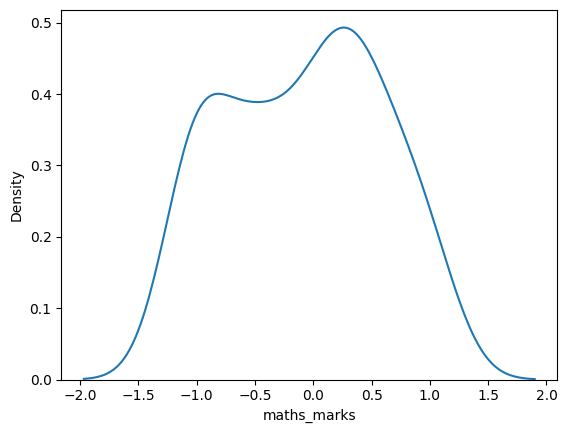

In [ ]:
sns.kdeplot(data=df, x="maths_marks")

In [ ]:
df['maths_marks'].describe()

,maths_marks
count,100.000000
mean,-0.082081
std,0.670519
min,-1.167630
25%,-0.589595
50%,0.000000
75%,0.410405
max,1.098266


# ColumnTransformer

*   Aother File.